### 타이어 마모 정도

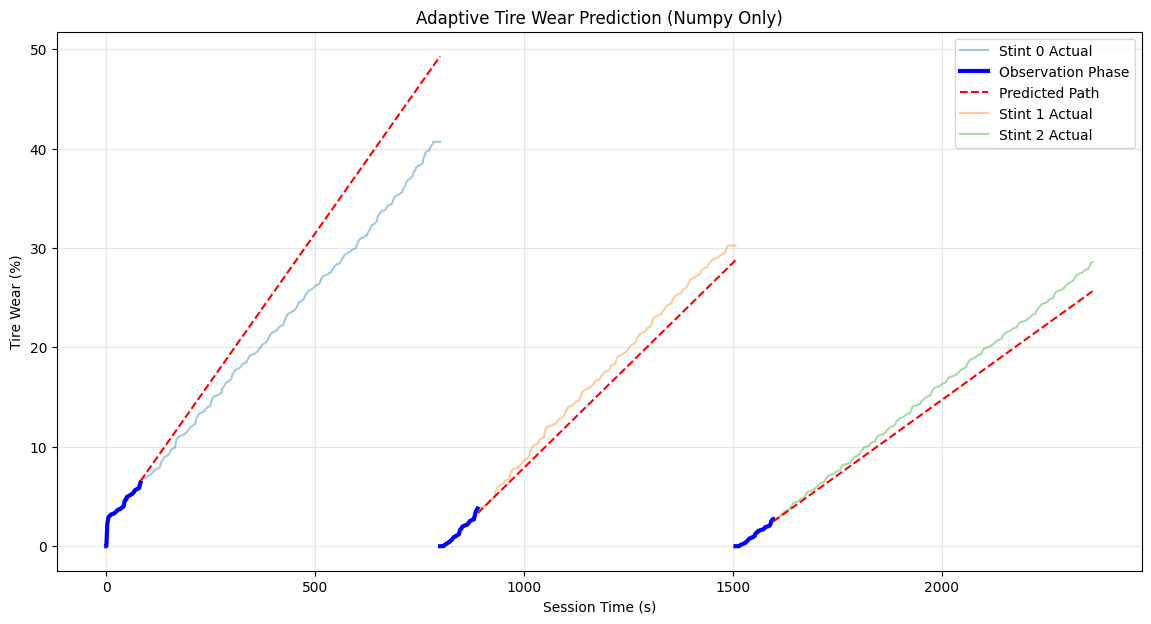

In [25]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def test_adaptive_prediction_no_sklearn(filepath, observation_minutes=1.5):
    # 1. 데이터 로드 및 전처리
    data_list = []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                d = json.loads(line)
                p_idx = d['m_header']['m_playerCarIndex']
                data_list.append({
                    'time': d['m_header']['m_sessionTime'],
                    'wear': d['m_carDamageData'][p_idx]['m_tyresWear'][0] 
                })
            except: continue
    
    df = pd.DataFrame(data_list)
    if df.empty: return print("데이터가 없습니다.")

    # 2. 피트스톱 감지 (마모도가 5% 이상 갑자기 줄어들면 새 타이어로 간주)
    df['stint'] = (df['wear'].diff() < -5).cumsum()
    
    plt.figure(figsize=(14, 7))
    
    # 3. 각 스틴트(Stint)별로 실험
    for stint_id, group in df.groupby('stint'):
        if len(group) < 500: continue
        
        group = group.reset_index(drop=True)
        
        # 관찰 윈도우 설정 (10Hz 기준)
        obs_limit = int(observation_minutes * 60 * 10)
        if len(group) <= obs_limit: continue
        
        obs_data = group.iloc[:obs_limit]
        future_data = group.iloc[obs_limit:]
        
        # [핵심] numpy.polyfit으로 선형 회귀 계산 ($y = ax + b$)
        # z[0]은 기울기(a), z[1]은 절편(b)이 됩니다.
        z = np.polyfit(obs_data['time'], obs_data['wear'], 1)
        predict_fn = np.poly1d(z)
        
        # 미래 데이터 예측
        y_pred = predict_fn(future_data['time'])
        
        # 4. 시각화
        plt.plot(group['time'], group['wear'], label=f'Stint {stint_id} Actual', alpha=0.4)
        plt.plot(obs_data['time'], obs_data['wear'], color='blue', linewidth=3, label='Observation Phase' if stint_id==0 else "")
        plt.plot(future_data['time'], y_pred, color='red', linestyle='--', label='Predicted Path' if stint_id==0 else "")

    plt.title(f"Adaptive Tire Wear Prediction (Numpy Only)")
    plt.xlabel("Session Time (s)")
    plt.ylabel("Tire Wear (%)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# 실행
test_adaptive_prediction_no_sklearn(r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza\record_damage.jsonl', observation_minutes=1.5)

📡 1. 랩 데이터를 포함한 모든 패킷 병합 중...


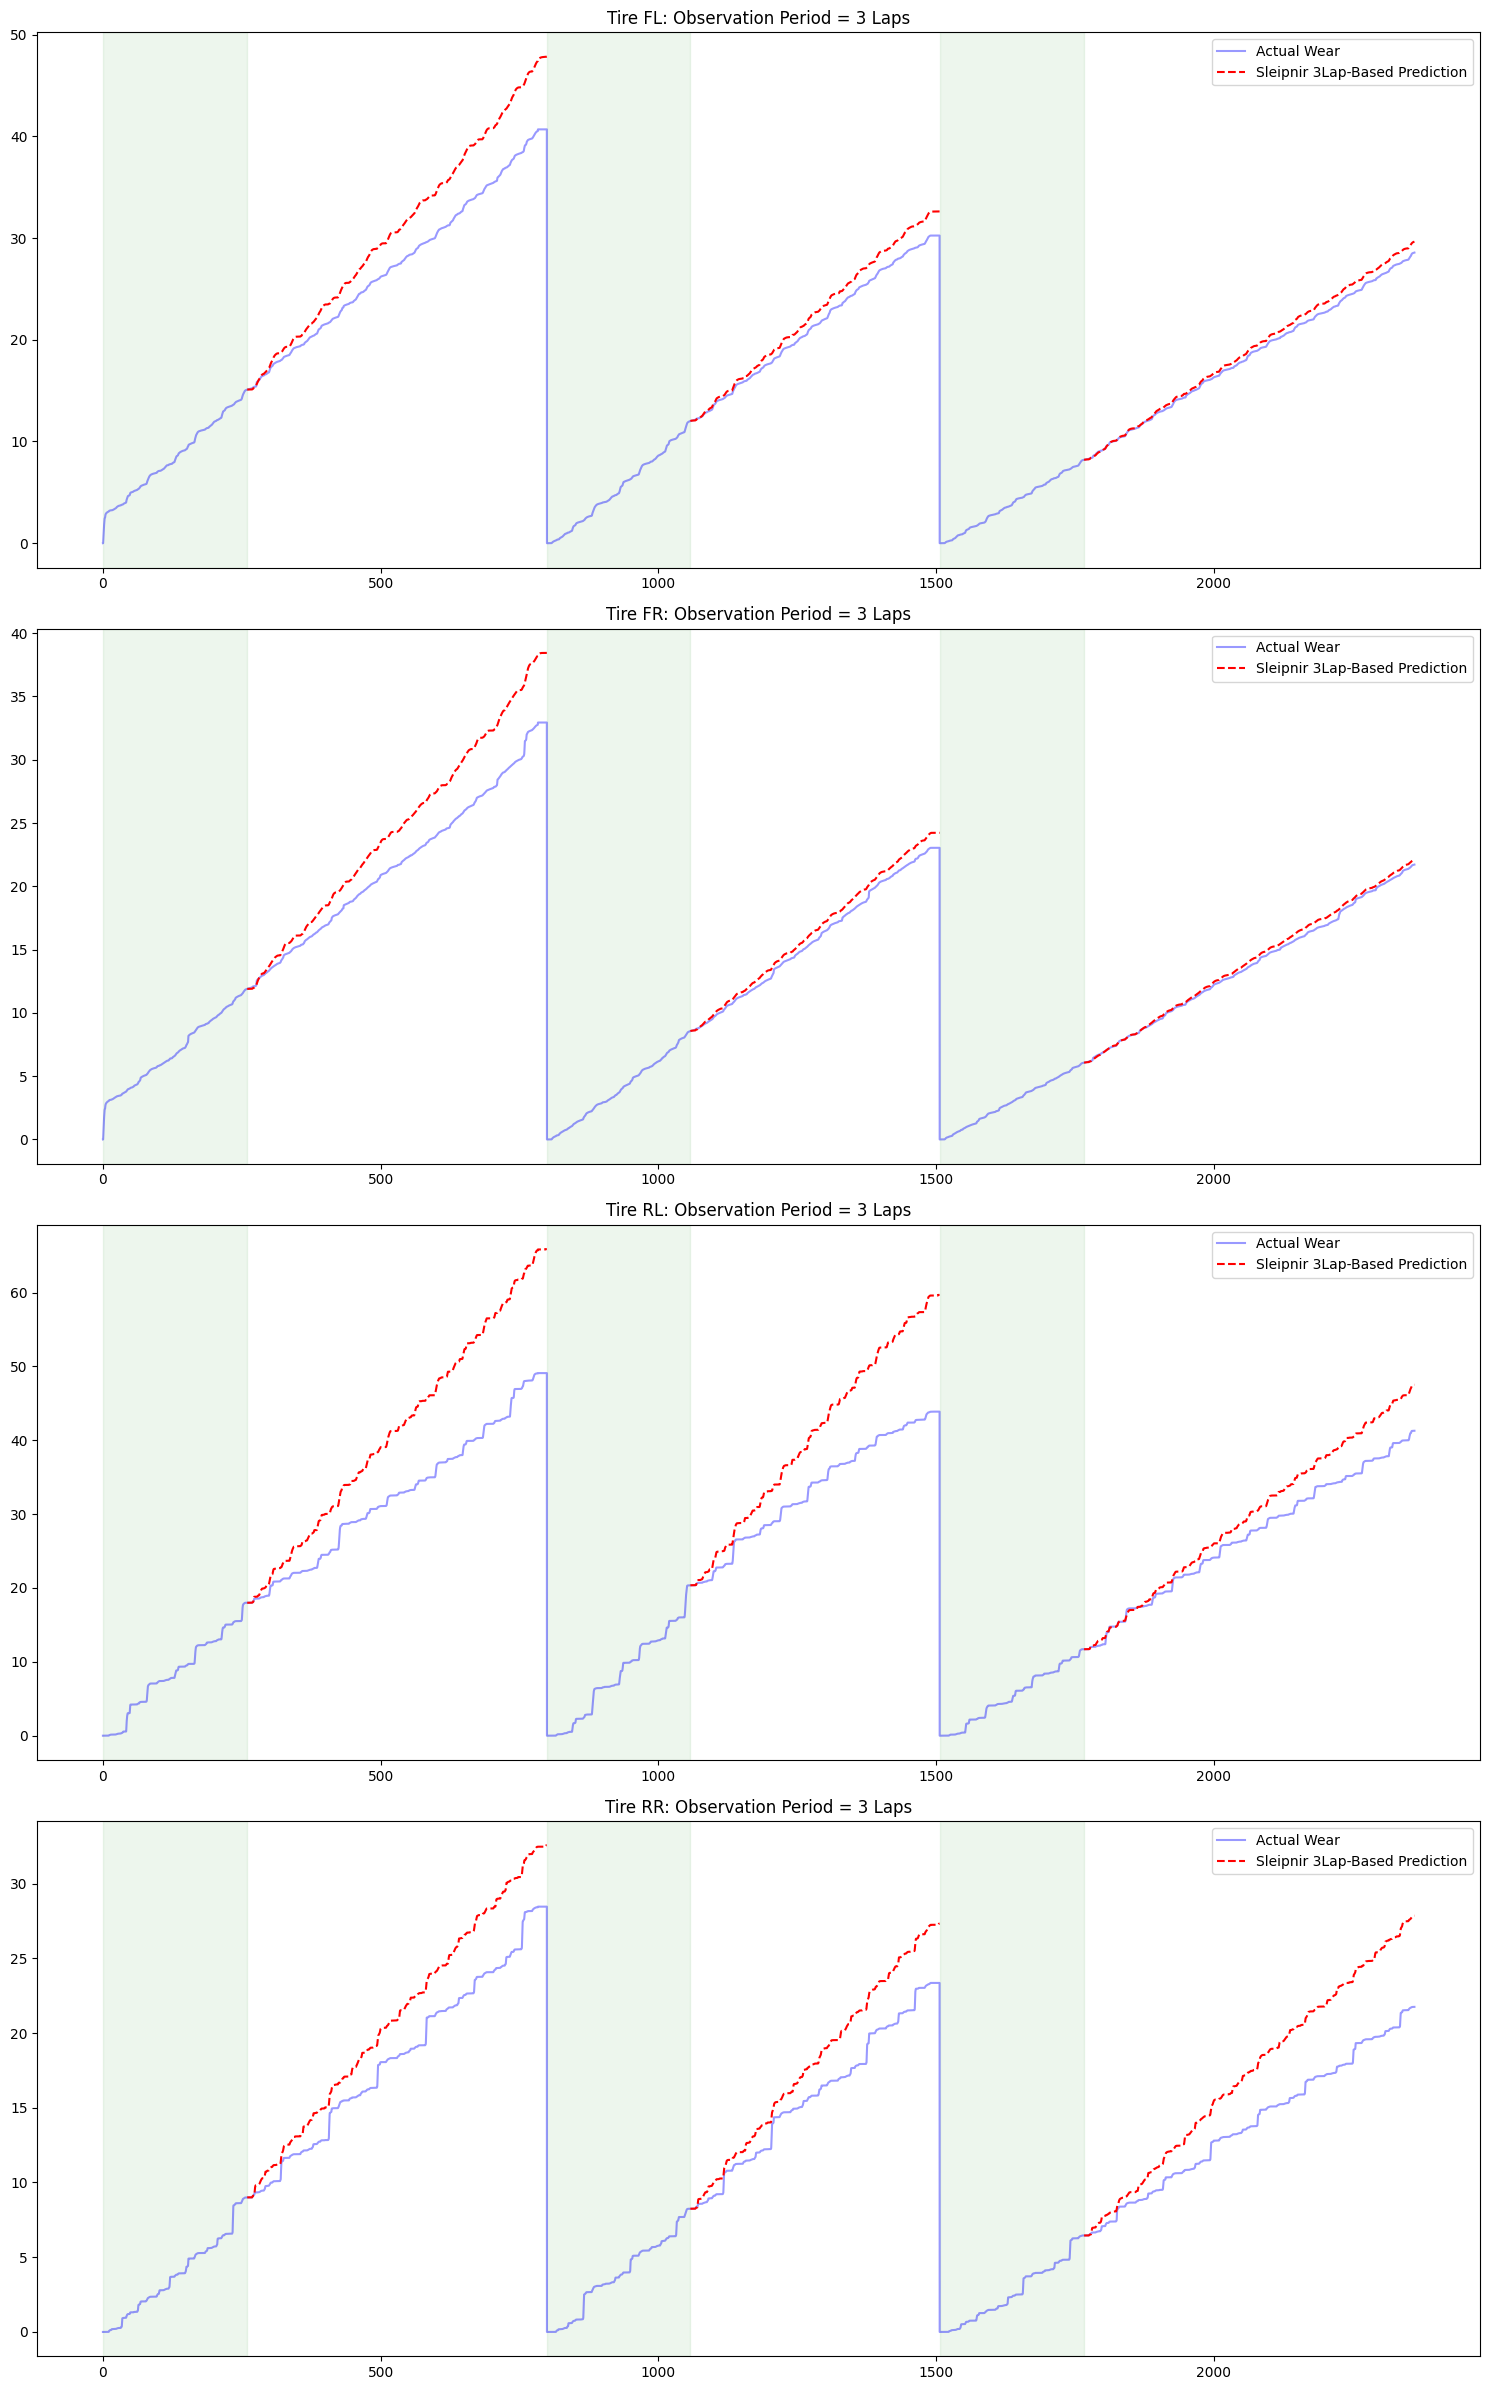

In [36]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

def load_all_packets_with_laps(damage_file, tele_file, motion_file, lap_file):
    def flatten(path, p_type):
        rows = []
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                try:
                    d = json.loads(line); idx = d['m_header']['m_playerCarIndex']; t = d['m_header']['m_sessionTime']
                    row = {'time': t}
                    if p_type == 'damage':
                        w = d['m_carDamageData'][idx]['m_tyresWear']
                        row['w_fl'], row['w_fr'], row['w_rl'], row['w_rr'] = w[0], w[1], w[2], w[3]
                    elif p_type == 'tele':
                        data = d['m_carTelemetryData'][idx]
                        row['brake'], row['steer'], row['speed'] = data['m_brake'], data['m_steer'], data['m_speed']
                        tmp = data['m_tyresSurfaceTemperature']
                        row['t_fl'], row['t_fr'], row['t_rl'], row['t_rr'] = tmp[0], tmp[1], tmp[2], tmp[3]
                    elif p_type == 'motion':
                        m_data = d['m_carMotionData'][idx]
                        row['g_lat'], row['g_lon'], row['g_vert'] = abs(m_data['m_gForceLateral']), abs(m_data['m_gForceLongitudinal']), abs(m_data['m_gForceVertical'])
                    elif p_type == 'lap':
                        # 현재 랩 번호 추출
                        row['lap_num'] = d['m_lapData'][idx]['m_currentLapNum']
                    rows.append(row)
                except: continue
        return pd.DataFrame(rows).sort_values('time')

    print("📡 1. 랩 데이터를 포함한 모든 패킷 병합 중...")
    df_d, df_t, df_m, df_l = flatten(damage_file, 'damage'), flatten(tele_file, 'tele'), flatten(motion_file, 'motion'), flatten(lap_file, 'lap')
    
    combined = pd.merge_asof(df_d, df_t, on='time', direction='nearest')
    combined = pd.merge_asof(combined, df_m, on='time', direction='nearest')
    combined = pd.merge_asof(combined, df_l, on='time', direction='nearest').dropna()
    return combined

def run_3lap_fixed_prediction(df, obs_laps=3):
    wheels = ['fl', 'fr', 'rl', 'rr']
    features_base = ['speed', 'brake', 'steer', 'g_lat', 'g_lon', 'g_vert']
    
    df['stint'] = (df['w_fl'].diff() < -5).cumsum()
    fig, axes = plt.subplots(4, 1, figsize=(15, 24))
    
    for i, w in enumerate(wheels):
        target_col = f'w_{w}'
        wheel_features = features_base + [f't_{w}']
        df[f'pred_{w}'] = np.nan

        for s_id, stint_data in df.groupby('stint'):
            if len(stint_data) < 100: continue
            
            # [핵심] 3랩 관찰 로직
            start_lap = stint_data['lap_num'].iloc[0]
            # 스틴트 시작 랩 번호 + obs_laps가 되는 시점을 찾음
            obs_mask = stint_data['lap_num'] < (start_lap + obs_laps)
            
            # 만약 스틴트 전체가 3랩보다 짧으면 절반만 사용 (예외 처리)
            if obs_mask.all():
                split_idx = len(stint_data) // 2
                obs_set = stint_data.iloc[:split_idx].copy()
                future_set = stint_data.iloc[split_idx:].copy()
            else:
                obs_set = stint_data[obs_mask].copy()
                future_set = stint_data[~obs_mask].copy()
            
            # 학습 및 델타 예측 (v8.0 로직 계승)
            obs_set['delta_w'] = obs_set[target_col].diff().fillna(0)
            model = LinearRegression()
            model.fit(obs_set[wheel_features], obs_set['delta_w'])
            
            future_deltas = model.predict(future_set[wheel_features])
            current_w = obs_set[target_col].iloc[-1]
            predictions = []
            for d in future_deltas:
                current_w += max(0, d)
                predictions.append(current_w)
            
            df.loc[future_set.index, f'pred_{w}'] = predictions

        # 시각화 (동일)
        axes[i].plot(df['time'], df[target_col], label='Actual Wear', color='blue', alpha=0.4)
        axes[i].plot(df['time'], df[f'pred_{w}'], label=f'Sleipnir {obs_laps}Lap-Based Prediction', color='red', linestyle='--')
        
        # 3랩 관찰 종료 시점 시각화
        for s_id, group in df.groupby('stint'):
            start_lap = group['lap_num'].iloc[0]
            obs_end_data = group[group['lap_num'] < (start_lap + obs_laps)]
            if not obs_end_data.empty:
                axes[i].axvspan(group['time'].min(), obs_end_data['time'].max(), color='green', alpha=0.07)

        axes[i].set_title(f"Tire {w.upper()}: Observation Period = {obs_laps} Laps")
        axes[i].legend()

    plt.tight_layout()
    plt.show()

# --- 실행부 ---
# path_lap = r'D:\...\record_lap.jsonl' # 랩 데이터 경로 추가 필요
combined_v9 = load_all_packets_with_laps(r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza\record_damage.jsonl',
                                        r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza\record_telemetry.jsonl',
                                          r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza\record_motion.jsonl',
                                        r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza\record_lap.jsonl')
run_3lap_fixed_prediction(combined_v9, obs_laps=3)

📡 1. 랩 데이터를 포함한 모든 패킷 병합 중...


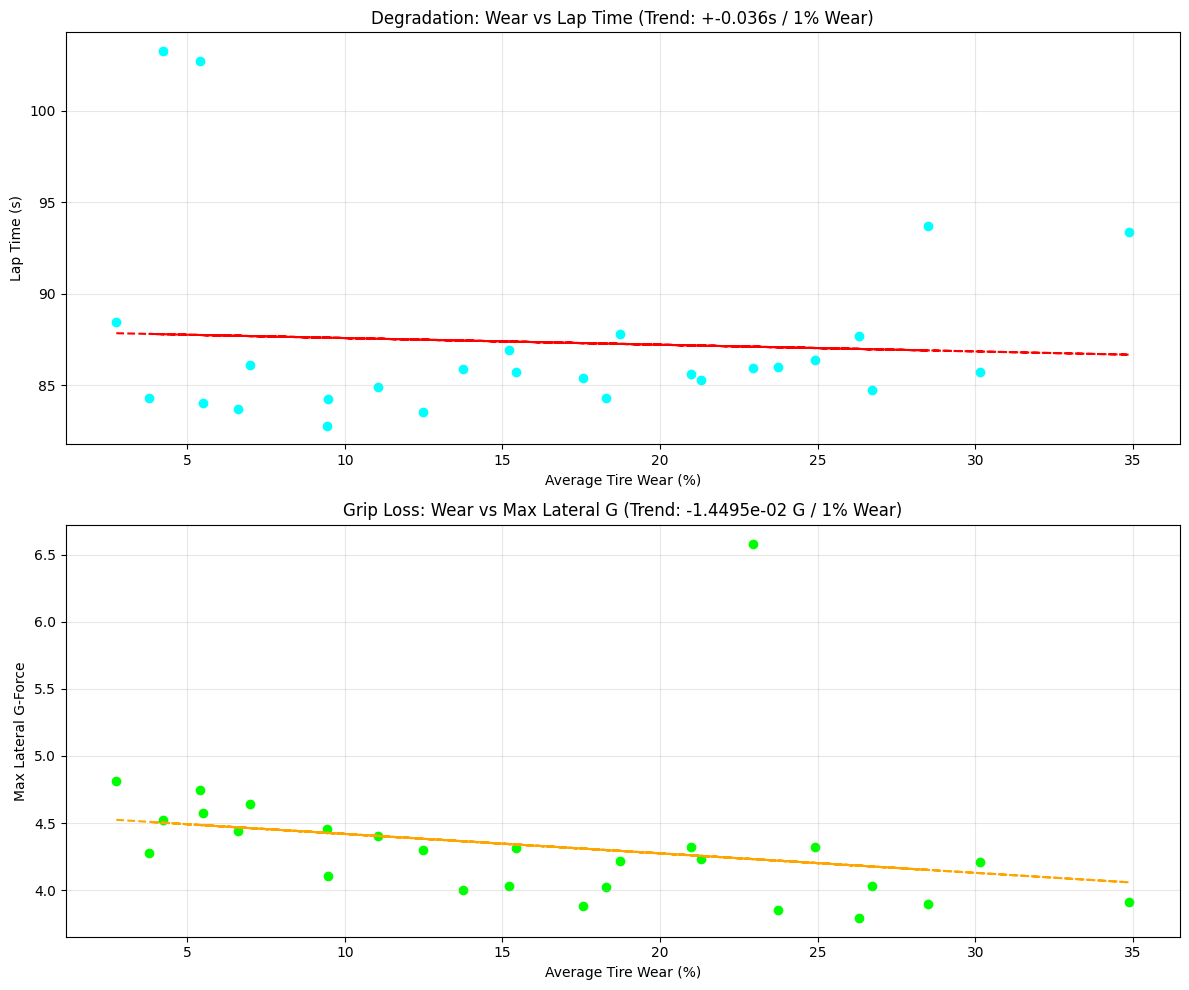


[Sleipnir v10 Analysis Result]
>>> 타이어가 1% 마모될 때마다 랩타임은 약 -0.0365초 느려집니다.
>>> 타이어가 1% 마모될 때마다 최대 그립력(G)은 약 0.0145만큼 감소합니다.


In [37]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

def load_integrated_data(damage_file, tele_file, motion_file, lap_file):
    # [기존 flatten 로직과 동일하게 데이터 로드]
    # (코드 중략: 이전 load_all_packets_with_laps 함수와 동일)
    combined = load_all_packets_with_laps(damage_file, tele_file, motion_file, lap_file)
    return combined

def run_performance_deg_analysis(df):
    """
    마모도와 성능(G-Force, Lap Time) 사이의 상관관계를 분석합니다.
    """
    # 1. 랩 단위 데이터 요약
    # 각 랩에서의 평균 마모도, 최대 횡G, 랩타임을 추출합니다.
    lap_stats = []
    for lap_num, group in df.groupby('lap_num'):
        if len(group) < 50: continue # 불완전한 데이터 제외
        
        avg_wear = group[['w_fl', 'w_fr', 'w_rl', 'w_rr']].mean().mean()
        max_g = group['g_lat'].max()
        lap_time = group['time'].max() - group['time'].min()
        
        lap_stats.append({
            'lap_num': lap_num,
            'avg_wear': avg_wear,
            'max_g': max_g,
            'lap_time': lap_time
        })
    
    summary_df = pd.DataFrame(lap_stats)
    
    # 2. 성능 저하 상관관계 모델링
    # 마모도(X)에 따른 랩타임 증가(y) 선형 회귀
    model_time = LinearRegression()
    X_wear = summary_df[['avg_wear']]
    model_time.fit(X_wear, summary_df['lap_time'])
    deg_rate_time = model_time.coef_[0]
    
    # 마모도(X)에 따른 최대 그립력(y) 감소 선형 회귀
    model_g = LinearRegression()
    model_g.fit(X_wear, summary_df['max_g'])
    deg_rate_g = model_g.coef_[0]

    # 3. 결과 시각화
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # (1) Wear vs Lap Time
    ax1.scatter(summary_df['avg_wear'], summary_df['lap_time'], color='cyan', label='Data Points')
    ax1.plot(summary_df['avg_wear'], model_time.predict(X_wear), color='red', linestyle='--')
    ax1.set_title(f"Degradation: Wear vs Lap Time (Trend: +{deg_rate_time:.3f}s / 1% Wear)")
    ax1.set_xlabel("Average Tire Wear (%)")
    ax1.set_ylabel("Lap Time (s)")
    ax1.grid(alpha=0.3)

    # (2) Wear vs Max G-Force (Grip)
    ax2.scatter(summary_df['avg_wear'], summary_df['max_g'], color='lime', label='Data Points')
    ax2.plot(summary_df['avg_wear'], model_g.predict(X_wear), color='orange', linestyle='--')
    ax2.set_title(f"Grip Loss: Wear vs Max Lateral G (Trend: {deg_rate_g:.4e} G / 1% Wear)")
    ax2.set_xlabel("Average Tire Wear (%)")
    ax2.set_ylabel("Max Lateral G-Force")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return deg_rate_time, deg_rate_g

# --- 실행부 ---
# 경로 설정 (사용자 경로에 맞춰 수정)
path_base = r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza'
combined_v10 = load_all_packets_with_laps(
    f"{path_base}\\record_damage.jsonl",
    f"{path_base}\\record_telemetry.jsonl",
    f"{path_base}\\record_motion.jsonl",
    f"{path_base}\\record_lap.jsonl"
)

time_deg, grip_deg = run_performance_deg_analysis(combined_v10)

print(f"\n[Sleipnir v10 Analysis Result]")
print(f">>> 타이어가 1% 마모될 때마다 랩타임은 약 {time_deg:.4f}초 느려집니다.")
print(f">>> 타이어가 1% 마모될 때마다 최대 그립력(G)은 약 {abs(grip_deg):.4f}만큼 감소합니다.")

### 연료 소모량 예측

✅ 세션 정보 확인: 총 36랩 레이스
📡 주행 데이터를 병합하고 있습니다...


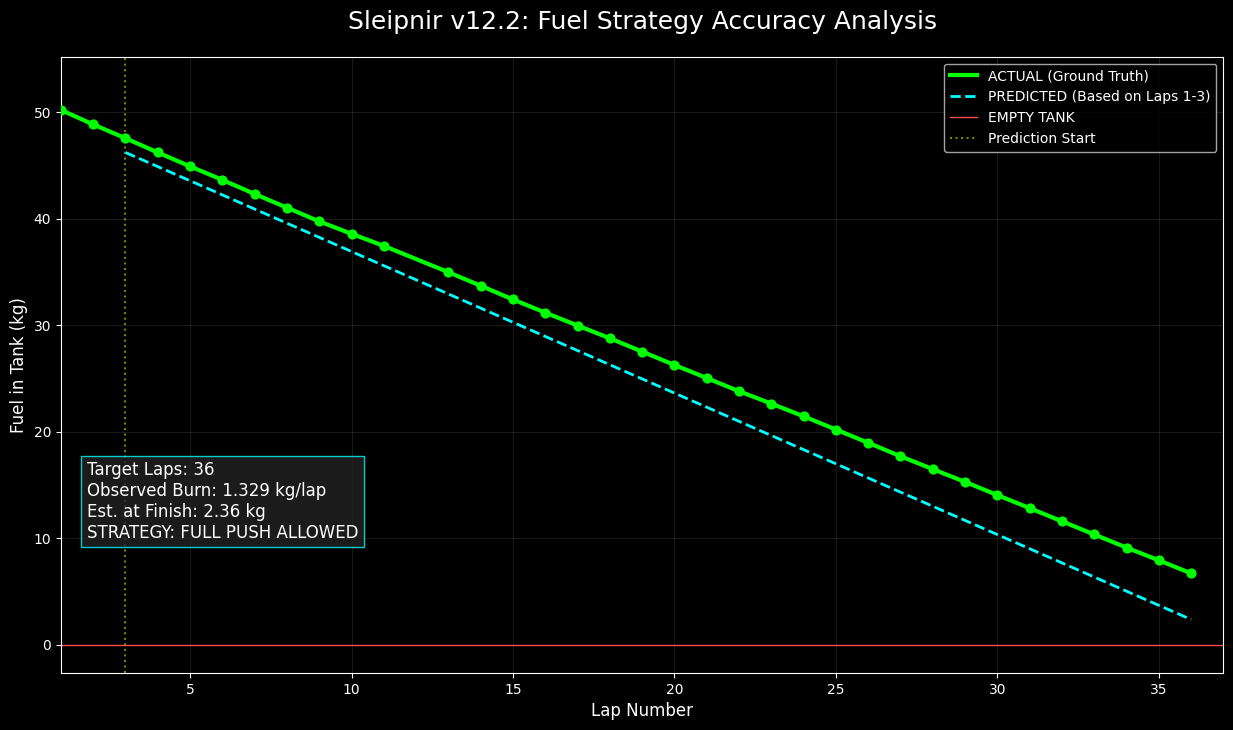

In [5]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def get_total_laps(session_file):
    """record_session.jsonl 파일에서 총 레이스 랩수를 자동으로 추출합니다."""
    try:
        with open(session_file, 'r', encoding='utf-8') as f:
            for line in f:
                d = json.loads(line)
                # Packet ID 1: PacketSessionData
                if d['m_header']['m_packetId'] == 1:
                    total_laps = d.get('m_totalLaps', 0)
                    if total_laps > 0:
                        print(f"✅ 세션 정보 확인: 총 {total_laps}랩 레이스")
                        return total_laps
    except Exception as e:
        print(f"⚠️ 세션 파일 읽기 실패: {e}")
    
    print("⚠️ 총 랩수를 찾지 못해 기본값(53랩)을 사용합니다.")
    return 53

def generate_sleipnir_v12_2_strategy(tele_file, status_file, lap_file, session_file):
    # 1. 총 랩수 자동 획득
    total_laps = get_total_laps(session_file)

    def load_packet_data(path, p_type):
        rows = []
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                try:
                    d = json.loads(line)
                    idx = d['m_header']['m_playerCarIndex']
                    t = d['m_header']['m_sessionTime']
                    row = {'time': t}
                    if p_type == 'tele':
                        data = d['m_carTelemetryData'][idx]
                        row['throttle'], row['rpm'] = data['m_throttle'], data['m_engineRPM']
                    elif p_type == 'status':
                        data = d['m_carStatusData'][idx]
                        row['fuel_in_tank'] = data['m_fuelInTank']
                    elif p_type == 'lap':
                        data = d['m_lapData'][idx]
                        row['lap_num'] = data['m_currentLapNum']
                    rows.append(row)
                except: continue
        return pd.DataFrame(rows).sort_values('time')

    # 2. 데이터 로드 및 병합
    print("📡 주행 데이터를 병합하고 있습니다...")
    df_t = load_packet_data(tele_file, 'tele')
    df_s = load_packet_data(status_file, 'status')
    df_l = load_packet_data(lap_file, 'lap')
    
    combined = pd.merge_asof(df_t, df_s, on='time', direction='nearest')
    combined = pd.merge_asof(combined, df_l, on='time', direction='nearest').dropna()

    # 3. 실제 전체 데이터 요약 (실선용)
    actual_lap_data = combined.groupby('lap_num')['fuel_in_tank'].first()

    # 4. 첫 3랩 기반 예측 로직 (점선용)
    all_laps = sorted(combined['lap_num'].unique())
    obs_laps = all_laps[:3]
    df_obs = combined[combined['lap_num'].isin(obs_laps)]
    
    # 3랩간의 평균 소모량 계산
    fuel_start = df_obs.groupby('lap_num')['fuel_in_tank'].first()
    avg_burn = fuel_start.diff().abs().mean()
    
    if pd.isna(avg_burn): # 데이터 부족 시 보정
        avg_burn = (df_obs['fuel_in_tank'].iloc[0] - df_obs['fuel_in_tank'].iloc[-1]) / len(obs_laps)

    # 5. 예측 데이터 생성 (3랩 끝점부터 총 랩수까지)
    last_obs_lap = obs_laps[-1]
    last_obs_fuel = df_obs['fuel_in_tank'].iloc[-1]
    
    future_x = np.arange(last_obs_lap, total_laps + 1)
    future_y = last_obs_fuel - (avg_burn * (future_x - last_obs_lap))
    
    # 엔진 정지 시점 계산
    death_lap = last_obs_lap + (last_obs_fuel / avg_burn)

    # 6. 시각화
    plt.figure(figsize=(15, 8))
    plt.style.use('dark_background')

    # [실제 데이터] 전체 주행 구간 - 굵은 초록색 실선
    plt.plot(actual_lap_data.index, actual_lap_data.values, 
             color='#00ff00', linewidth=3, label='ACTUAL (Ground Truth)', zorder=10)
    plt.scatter(actual_lap_data.index, actual_lap_data.values, color='#00ff00', s=40, zorder=11)

    # [예측 데이터] 3랩 이후 구간 - 하늘색 점선
    plt.plot(future_x, future_y, 
             color='#00ffff', linestyle='--', linewidth=2, label=f'PREDICTED (Based on Laps {obs_laps[0]}-{obs_laps[-1]})', zorder=5)

    # 기준선 및 강조
    plt.axhline(0, color='#ff4d4d', linestyle='-', linewidth=1, label='EMPTY TANK')
    plt.axvline(last_obs_lap, color='yellow', linestyle=':', alpha=0.5, label='Prediction Start')

    # 엔진 정지 표기
    if death_lap <= total_laps:
        plt.scatter(death_lap, 0, color='red', s=150, marker='X', zorder=20)
        plt.annotate(f'STALL AT LAP {death_lap:.1f}', (death_lap, 2), color='red', weight='bold', ha='center')

    # 그래프 서식
    plt.title(f'Sleipnir v12.2: Fuel Strategy Accuracy Analysis', fontsize=18, pad=20)
    plt.xlabel('Lap Number', fontsize=12)
    plt.ylabel('Fuel in Tank (kg)', fontsize=12)
    plt.ylim(min(future_y.min(), actual_lap_data.min()) - 5, actual_lap_data.max() + 5)
    plt.xlim(1, total_laps + 1)
    plt.grid(True, alpha=0.1)
    plt.legend(loc='upper right')

    # 전략 리포트 텍스트
    finish_fuel = future_y[-1]
    status = "LIFT & COAST REQUIRED" if finish_fuel < 0 else "FULL PUSH ALLOWED"
    report = (f"Target Laps: {total_laps}\n"
              f"Observed Burn: {avg_burn:.3f} kg/lap\n"
              f"Est. at Finish: {finish_fuel:.2f} kg\n"
              f"STRATEGY: {status}")
    
    plt.text(total_laps*0.05, actual_lap_data.max()*0.2, report, fontsize=12, 
             color='white', bbox=dict(facecolor='#222222', alpha=0.8, edgecolor='cyan'))

    plt.show()

# --- 실행부 ---
path_base = r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\Zandvoort'
generate_sleipnir_v12_2_strategy(
    f"{path_base}\\record_telemetry.jsonl",
    f"{path_base}\\record_status.jsonl",
    f"{path_base}\\record_lap.jsonl",
    f"{path_base}\\record_session.jsonl" # 세션 파일 추가
)

### 엔진 데미지 예측

📡 텔레메트리 및 데미지 데이터 병합 중...


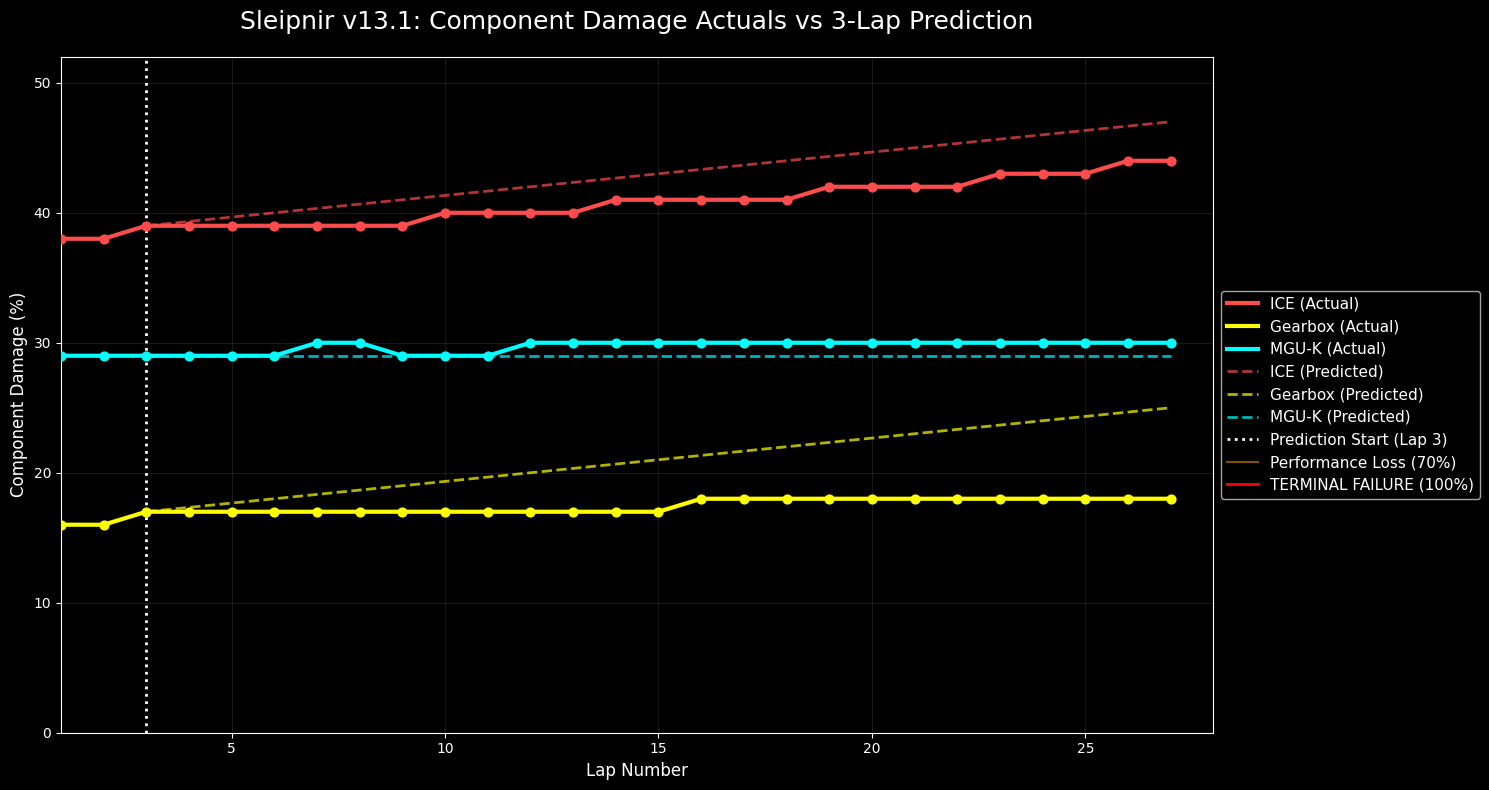

In [8]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def generate_sleipnir_v13_1_damage_model(tele_file, damage_file, lap_file, session_file):
    # 1. 세션 총 랩수 가져오기
    total_laps = 53
    try:
        with open(session_file, 'r', encoding='utf-8') as f:
            for line in f:
                d = json.loads(line)
                if d['m_header']['m_packetId'] == 1 and d.get('m_totalLaps', 0) > 0:
                    total_laps = d['m_totalLaps']
                    break
    except: pass

    # 2. 데이터 로드 및 병합 (KeyError 방지 적용)
    def load_packet_data(path, p_type):
        rows = []
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                try:
                    d = json.loads(line)
                    idx = d['m_header']['m_playerCarIndex']
                    t = d['m_header']['m_sessionTime']
                    row = {'time': t}
                    if p_type == 'tele':
                        data = d['m_carTelemetryData'][idx]
                        row['throttle'] = data['m_throttle']
                        row['brake'] = data['m_brake']
                        row['rpm'] = data['m_engineRPM']
                        row['temp'] = data['m_engineTemperature']
                    elif p_type == 'damage':
                        data = d['m_carDamageData'][idx]
                        # 공식 UDP 명세 키값 매칭 및 get 방어
                        row['ice_wear'] = data.get('m_engineICEWear', 0)
                        row['gearbox_damage'] = data.get('m_gearBoxDamage', 0)
                        row['mguk_wear'] = data.get('m_engineMGUKWear', 0)
                    elif p_type == 'lap':
                        row['lap_num'] = d['m_lapData'][idx]['m_currentLapNum']
                    rows.append(row)
                except: continue
        
        df = pd.DataFrame(rows)
        if df.empty:
            raise ValueError(f"❌ '{p_type}' 데이터를 파싱하지 못했습니다.")
        return df.sort_values('time')

    print("📡 텔레메트리 및 데미지 데이터 병합 중...")
    df_t = load_packet_data(tele_file, 'tele')
    df_d = load_packet_data(damage_file, 'damage')
    df_l = load_packet_data(lap_file, 'lap')
    
    combined = pd.merge_asof(df_t, df_d, on='time', direction='nearest')
    combined = pd.merge_asof(combined, df_l, on='time', direction='nearest').dropna()

    # 3. 전체 실제 데미지 데이터 (Ground Truth)
    # 각 랩의 마지막 시점 데미지를 기준값으로 잡음
    actual_damage = combined.groupby('lap_num')[['ice_wear', 'gearbox_damage', 'mguk_wear']].last()

    # 4. 모델 학습 (오직 1~3랩 데이터만 활용)
    all_laps = sorted(combined['lap_num'].unique())
    obs_laps = all_laps[:3]
    df_obs = combined[combined['lap_num'].isin(obs_laps)].copy()

    damage_start = df_obs.groupby('lap_num').first()
    damage_end = df_obs.groupby('lap_num').last()
    
    # 랩당 평균 데미지 증가율 (마이너스 방지)
    avg_ice_rate = max(0, (damage_end['ice_wear'].iloc[-1] - damage_start['ice_wear'].iloc[0]) / len(obs_laps))
    avg_gear_rate = max(0, (damage_end['gearbox_damage'].iloc[-1] - damage_start['gearbox_damage'].iloc[0]) / len(obs_laps))
    avg_mguk_rate = max(0, (damage_end['mguk_wear'].iloc[-1] - damage_start['mguk_wear'].iloc[0]) / len(obs_laps))

    # 5. 미래 블라인드 예측 계산
    last_obs_lap = obs_laps[-1]
    current_ice = damage_end['ice_wear'].iloc[-1]
    current_gear = damage_end['gearbox_damage'].iloc[-1]
    current_mguk = damage_end['mguk_wear'].iloc[-1]

    future_x = np.arange(last_obs_lap, total_laps + 1)
    
    pred_ice = current_ice + (avg_ice_rate * (future_x - last_obs_lap))
    pred_gear = current_gear + (avg_gear_rate * (future_x - last_obs_lap))
    pred_mguk = current_mguk + (avg_mguk_rate * (future_x - last_obs_lap))

    # 6. 시각화 (실제 vs 예측)
    plt.figure(figsize=(15, 8))
    plt.style.use('dark_background')

    actual_x = actual_damage.index

    # [A] 전체 실제 데이터 (굵은 실선)
    plt.plot(actual_x, actual_damage['ice_wear'], color='#ff4d4d', linewidth=3, label='ICE (Actual)', zorder=10)
    plt.plot(actual_x, actual_damage['gearbox_damage'], color='#ffff00', linewidth=3, label='Gearbox (Actual)', zorder=10)
    plt.plot(actual_x, actual_damage['mguk_wear'], color='#00ffff', linewidth=3, label='MGU-K (Actual)', zorder=10)

    # 데이터 포인트 표시
    plt.scatter(actual_x, actual_damage['ice_wear'], color='#ff4d4d', s=40, zorder=11)
    plt.scatter(actual_x, actual_damage['gearbox_damage'], color='#ffff00', s=40, zorder=11)
    plt.scatter(actual_x, actual_damage['mguk_wear'], color='#00ffff', s=40, zorder=11)

    # [B] 첫 3랩 기반 예측선 (점선)
    plt.plot(future_x, pred_ice, color='#ff4d4d', linestyle='--', linewidth=2, alpha=0.7, label='ICE (Predicted)')
    plt.plot(future_x, pred_gear, color='#ffff00', linestyle='--', linewidth=2, alpha=0.7, label='Gearbox (Predicted)')
    plt.plot(future_x, pred_mguk, color='#00ffff', linestyle='--', linewidth=2, alpha=0.7, label='MGU-K (Predicted)')

    # [C] 기준선 및 한계선
    plt.axvline(last_obs_lap, color='white', linestyle=':', linewidth=2, label='Prediction Start (Lap 3)')
    plt.axhline(70, color='orange', linestyle='-', alpha=0.5, label='Performance Loss (70%)')
    plt.axhline(100, color='red', linestyle='-', linewidth=2, label='TERMINAL FAILURE (100%)')

    plt.title(f'Sleipnir v13.1: Component Damage Actuals vs 3-Lap Prediction', fontsize=18, pad=20)
    plt.xlabel('Lap Number', fontsize=12)
    plt.ylabel('Component Damage (%)', fontsize=12)
    
    # Y축 범위를 데이터에 맞게 최적화 (단, 최대 105%까지만)
    max_val = max(actual_damage.max().max(), pred_ice[-1], pred_gear[-1], pred_mguk[-1])
    plt.ylim(0, min(105, max_val + 5))
    plt.xlim(1, total_laps + 1)
    
    plt.grid(True, alpha=0.1)
    
    # 범례가 그래프를 가리지 않도록 밖으로 배치
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), prop={'size': 11})
    plt.tight_layout()

    plt.show()

# --- 실행 경로 (사용자 환경에 맞게 조정) ---
base_path = r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza'
generate_sleipnir_v13_1_damage_model(
    f"{base_path}\\record_telemetry.jsonl",
    f"{base_path}\\record_damage.jsonl",
    f"{base_path}\\record_lap.jsonl",
    f"{base_path}\\record_session.jsonl"
)

d:\code\Collection_of_virtual\SLM_space\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
d:\code\Collection_of_virtual\SLM_space\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
d:\code\Collection_of_virtual\SLM_space\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


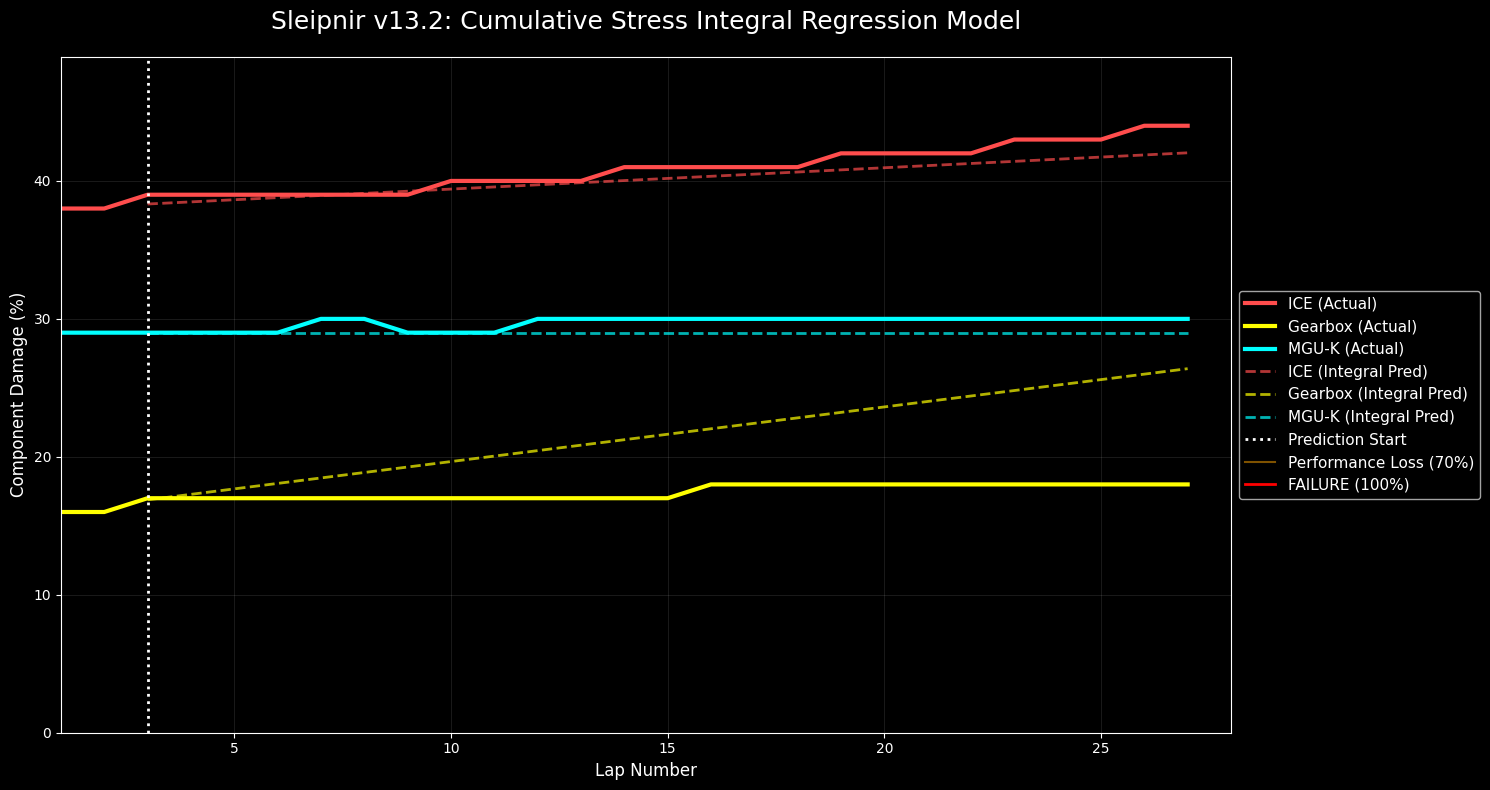

In [9]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

def generate_sleipnir_v13_2_integral_model(tele_file, damage_file, lap_file, session_file):
    # 1. 총 랩수 파싱
    total_laps = 53
    try:
        with open(session_file, 'r', encoding='utf-8') as f:
            for line in f:
                d = json.loads(line)
                if d['m_header']['m_packetId'] == 1 and d.get('m_totalLaps', 0) > 0:
                    total_laps = d['m_totalLaps']
                    break
    except: pass

    # 2. 데이터 병합
    def load_packet_data(path, p_type):
        rows = []
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                try:
                    d = json.loads(line)
                    idx = d['m_header']['m_playerCarIndex']
                    t = d['m_header']['m_sessionTime']
                    row = {'time': t}
                    if p_type == 'tele':
                        data = d['m_carTelemetryData'][idx]
                        row['throttle'] = data['m_throttle']
                        row['brake'] = data['m_brake']
                        row['rpm'] = data['m_engineRPM']
                        row['temp'] = data['m_engineTemperature']
                    elif p_type == 'damage':
                        data = d['m_carDamageData'][idx]
                        row['ice_wear'] = data.get('m_engineICEWear', 0)
                        row['gearbox_damage'] = data.get('m_gearBoxDamage', 0)
                        row['mguk_wear'] = data.get('m_engineMGUKWear', 0)
                    elif p_type == 'lap':
                        row['lap_num'] = d['m_lapData'][idx]['m_currentLapNum']
                    rows.append(row)
                except: continue
        
        df = pd.DataFrame(rows)
        if df.empty: raise ValueError(f"❌ '{p_type}' 데이터를 파싱하지 못했습니다.")
        return df.sort_values('time')

    df_t = load_packet_data(tele_file, 'tele')
    df_d = load_packet_data(damage_file, 'damage')
    df_l = load_packet_data(lap_file, 'lap')
    
    df = pd.merge_asof(df_t, df_d, on='time', direction='nearest')
    df = pd.merge_asof(df, df_l, on='time', direction='nearest').dropna()

    # ---------------------------------------------------------
    # 🌟 3. 순간 스트레스 계산 및 '적분(Cumulative Sum)' 적용
    # ---------------------------------------------------------
    # (1) 순간 스트레스 정의
    df['ice_stress_inst'] = df['throttle'] * (df['rpm'] / 10000) * (df['temp'] / 100)
    df['gear_stress_inst'] = df['brake'] * (df['rpm'] / 10000)
    df['mguk_stress_inst'] = df['brake'] + df['throttle']

    # (2) 누적 스트레스 (적분)
    df['ice_stress_cum'] = df['ice_stress_inst'].cumsum()
    df['gear_stress_cum'] = df['gear_stress_inst'].cumsum()
    df['mguk_stress_cum'] = df['mguk_stress_inst'].cumsum()

    # 4. 모델 학습 (1~3랩 데이터만 추출하여 회귀 모델 적합)
    all_laps = sorted(df['lap_num'].unique())
    obs_laps = all_laps[:3]
    df_obs = df[df['lap_num'].isin(obs_laps)].copy()

    # Linear Regression 모델 준비
    model_ice = LinearRegression()
    model_gear = LinearRegression()
    model_mguk = LinearRegression()

    # X: 누적 스트레스 (적분값), Y: 실제 마모도
    model_ice.fit(df_obs[['ice_stress_cum']], df_obs['ice_wear'])
    model_gear.fit(df_obs[['gear_stress_cum']], df_obs['gearbox_damage'])
    model_mguk.fit(df_obs[['mguk_stress_cum']], df_obs['mguk_wear'])

    # 5. 미래 데이터 예측
    last_obs_lap = obs_laps[-1]
    
    # "1랩당 발생하는 스트레스 적분량"의 평균을 구함
    ice_stress_per_lap = (df_obs['ice_stress_cum'].iloc[-1] - df_obs['ice_stress_cum'].iloc[0]) / len(obs_laps)
    gear_stress_per_lap = (df_obs['gear_stress_cum'].iloc[-1] - df_obs['gear_stress_cum'].iloc[0]) / len(obs_laps)
    mguk_stress_per_lap = (df_obs['mguk_stress_cum'].iloc[-1] - df_obs['mguk_stress_cum'].iloc[0]) / len(obs_laps)

    future_x_laps = np.arange(last_obs_lap, total_laps + 1)
    
    # 미래의 '누적 스트레스' 투사
    future_ice_stress = df_obs['ice_stress_cum'].iloc[-1] + (ice_stress_per_lap * (future_x_laps - last_obs_lap))
    future_gear_stress = df_obs['gear_stress_cum'].iloc[-1] + (gear_stress_per_lap * (future_x_laps - last_obs_lap))
    future_mguk_stress = df_obs['mguk_stress_cum'].iloc[-1] + (mguk_stress_per_lap * (future_x_laps - last_obs_lap))

    # 학습된 회귀 모델로 미래 데미지 예측
    pred_ice = model_ice.predict(future_ice_stress.reshape(-1, 1))
    pred_gear = model_gear.predict(future_gear_stress.reshape(-1, 1))
    pred_mguk = model_mguk.predict(future_mguk_stress.reshape(-1, 1))

    # 6. 시각화 (전체 실제 데이터 vs 적분 기반 예측 데이터)
    actual_lap_data = df.groupby('lap_num').last()
    actual_x = actual_lap_data.index

    plt.figure(figsize=(15, 8))
    plt.style.use('dark_background')

    # [A] 전체 실제 데이터
    plt.plot(actual_x, actual_lap_data['ice_wear'], color='#ff4d4d', linewidth=3, label='ICE (Actual)')
    plt.plot(actual_x, actual_lap_data['gearbox_damage'], color='#ffff00', linewidth=3, label='Gearbox (Actual)')
    plt.plot(actual_x, actual_lap_data['mguk_wear'], color='#00ffff', linewidth=3, label='MGU-K (Actual)')

    # [B] 적분 기반 예측선 (회귀 모델 결과)
    plt.plot(future_x_laps, pred_ice, color='#ff4d4d', linestyle='--', linewidth=2, alpha=0.7, label='ICE (Integral Pred)')
    plt.plot(future_x_laps, pred_gear, color='#ffff00', linestyle='--', linewidth=2, alpha=0.7, label='Gearbox (Integral Pred)')
    plt.plot(future_x_laps, pred_mguk, color='#00ffff', linestyle='--', linewidth=2, alpha=0.7, label='MGU-K (Integral Pred)')

    plt.axvline(last_obs_lap, color='white', linestyle=':', linewidth=2, label='Prediction Start')
    plt.axhline(70, color='orange', linestyle='-', alpha=0.5, label='Performance Loss (70%)')
    plt.axhline(100, color='red', linestyle='-', linewidth=2, label='FAILURE (100%)')

    plt.title(f'Sleipnir v13.2: Cumulative Stress Integral Regression Model', fontsize=18, pad=20)
    plt.xlabel('Lap Number', fontsize=12)
    plt.ylabel('Component Damage (%)', fontsize=12)
    
    max_val = max(actual_lap_data[['ice_wear', 'gearbox_damage', 'mguk_wear']].max().max(), 
                  pred_ice[-1], pred_gear[-1], pred_mguk[-1])
    plt.ylim(0, min(105, max_val + 5))
    plt.xlim(1, total_laps + 1)
    
    plt.grid(True, alpha=0.1)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), prop={'size': 11})
    plt.tight_layout()

    plt.show()

# --- 실행 ---
base_path = r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza'
generate_sleipnir_v13_2_integral_model(
    f"{base_path}\\record_telemetry.jsonl",
    f"{base_path}\\record_damage.jsonl",
    f"{base_path}\\record_lap.jsonl",
    f"{base_path}\\record_session.jsonl"
)